In [1]:
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
import seaborn as sns
sns.set()
sns.set_theme(style='whitegrid')

In [2]:
display_name = {'FedAvg': 'LS(FedAvg)', 'Tche': 'TCH', 'AFL': 'OMDgd-TCH(AFL)', 'AFLeg': 'OMDeg-TCH',
                'AFL_new': 'AdaOMDgd-TCH', 'AFLeg_new': 'AdaOMDeg-TCH'}
colors = {'FedAvg': 'r', 'Tche': 'darkgray', 
          'AFL': 'b', 'AFL_new': 'c', 'AFLeg': 'm', 'AFLeg_new': 'plum'}

In [3]:
def plot_scatters(ds_name, allocation_scheme, seeds, methods, ylimmin=90, ylimmax=100, xlimmin=0, xlimmax=5):
    fig, ax = plt.subplots(figsize=(6,6))

    data = {}
    xmin, xmax = float('inf'), 0.
    for method in methods:
        data[method] = [[], []] # average accuracy, accuracy parity
        for seed in seeds:
            path = f'../output/10seeds/{ds_name}_{allocation_scheme}/seed{seed}/{method}/log.pickle'
            with open(path, 'rb') as file:
                res = pickle.load(file)

            data[method][0].append(res[-1]['test_infer_stats']['mean_acc'])
            data[method][1].append(np.var(res[-1]['test_infer_stats']['accuracys']))
        
        data[method][0] = np.mean(data[method][0]) * 100
        data[method][1] = np.sqrt(np.mean(data[method][1]) * 10000)
        xmin = min(xmin, data[method][1])
        xmax = max(xmax, data[method][1])

    offset = (xmax - xmin) / 50
    for method in methods:
        method_name = method.split('_llr')[0]
        display = display_name[method_name]
        xval, yval = data[method][1], data[method][0]
        ax.scatter(xval, yval, color=colors[method_name], label=display, s=250 if 'new' in method_name else 150, 
                   zorder=1, marker='*' if 'new' in method_name else 'o')
        ax.plot([xlimmin, xval], [yval, yval], color=colors[method_name], linestyle='--', linewidth=1, zorder=-1)
        ax.plot([xval, xval], [ylimmin, yval], color=colors[method_name], linestyle='--', linewidth=1, zorder=-1)
        # ax.text(data[method][1]+offset, data[method][0]+offset, display, 
        #         color=colors[method_name], fontsize=12, ha='left', va='top')

    ax.set_xlim(xmin=xlimmin, xmax=xlimmax)
    ax.set_ylim(ymin=ylimmin, ymax=ylimmax)
    ax.set_xlabel(r"$\longleftarrow$ Test Accuracy Parity", fontsize=18)
    ax.set_ylabel(r"Average Test Accuracy $\longrightarrow$", fontsize=18)

    plt.legend(fontsize=15)
    if allocation_scheme == 'rotation':
        allocation_title = 'Rotation'
    if allocation_scheme == 'partial_class_ni2':
        allocation_title = 'Partial_Class_C=2'
    elif allocation_scheme == 'partial_class_ni5':
        allocation_title = 'Partial_Class_C=5'
    fig.suptitle(f'{ds_name} {allocation_title}', fontsize=20)
    fig.tight_layout()

    plt.savefig(f'figures/scatters/{ds_name}_{allocation_scheme}_scatters.pdf')
    plt.show()
    plt.close()

In [4]:
seeds = [0, 25, 37, 42, 53, 81, 119, 1010, 1201, 2003]

### MNIST

#### Rotation

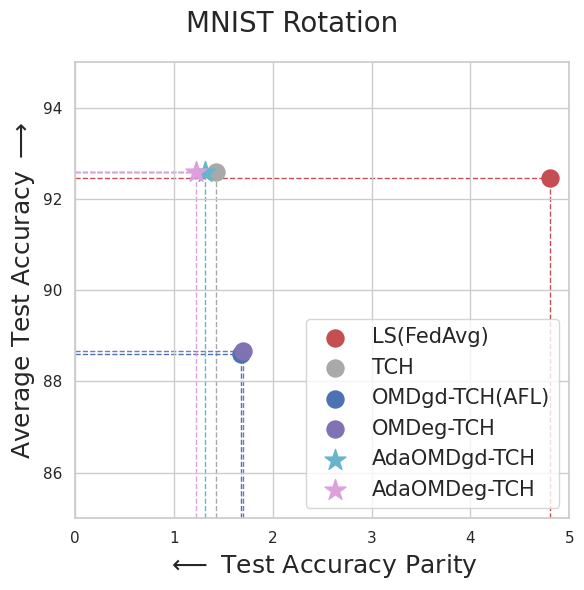

In [7]:
plot_scatters('MNIST', 'rotation', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr0.03', 'AFLeg_llr0.3', 'AFL_new_llr0.03', 'AFLeg_new_llr0.1'],
              ylimmin=85, ylimmax=95)

#### Partial_class_ni2

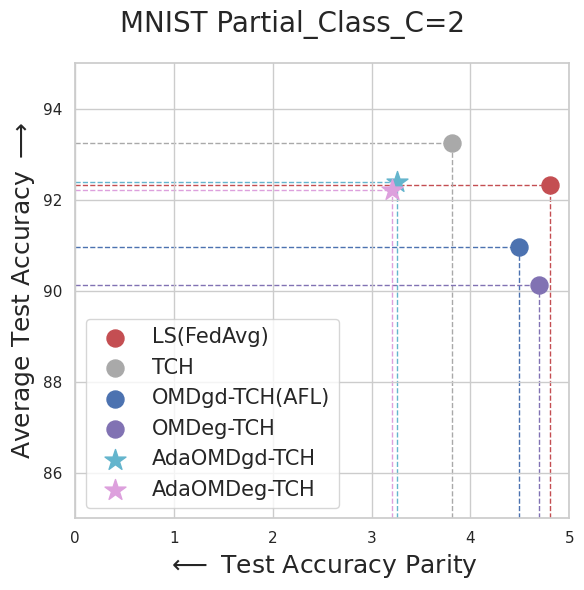

In [5]:
plot_scatters('MNIST', 'partial_class_ni2', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.3', 'AFL_new_llr1.0', 'AFLeg_new_llr0.3'],
              ylimmin=85, ylimmax=95)

#### Partial_class_ni5

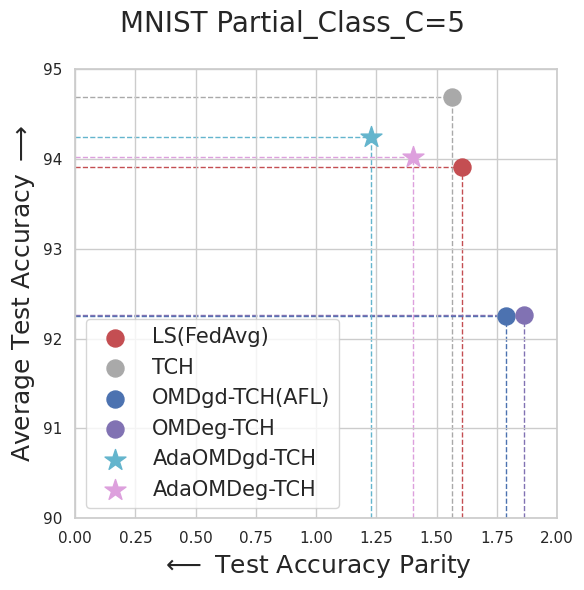

In [6]:
plot_scatters('MNIST', 'partial_class_ni5', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr1.0', 'AFLeg_new_llr0.03'],
              ylimmin=90, ylimmax=95, xlimmin=0, xlimmax=2)

### CIFAR10

#### Rotation

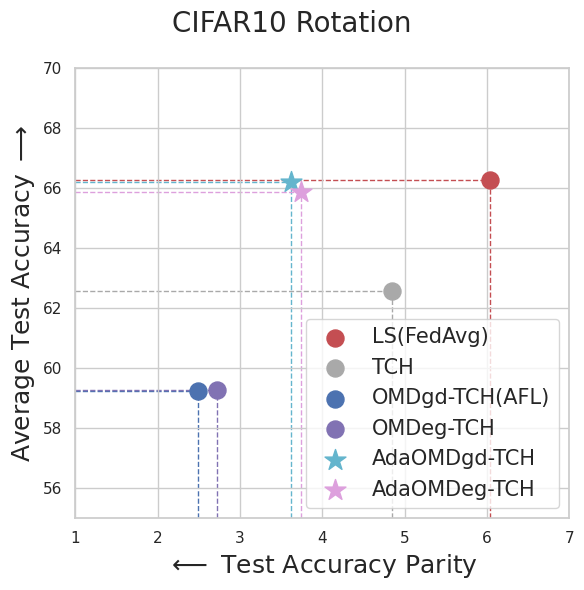

In [8]:
plot_scatters('CIFAR10', 'rotation', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr1.0', 'AFLeg_llr1.0', 'AFL_new_llr0.03', 'AFLeg_new_llr0.3'], 
              ylimmin=55, ylimmax=70, xlimmin=1, xlimmax=7)

#### Partial_class_ni2

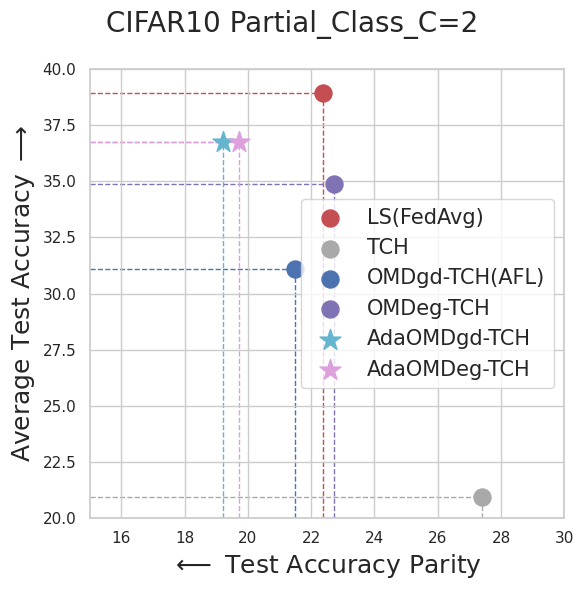

In [7]:
plot_scatters('CIFAR10', 'partial_class_ni2', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.03', 'AFL_new_llr0.003', 'AFLeg_new_llr0.03'], 
              ylimmin=20, ylimmax=40, xlimmin=15, xlimmax=30)

#### Partial_class_ni5

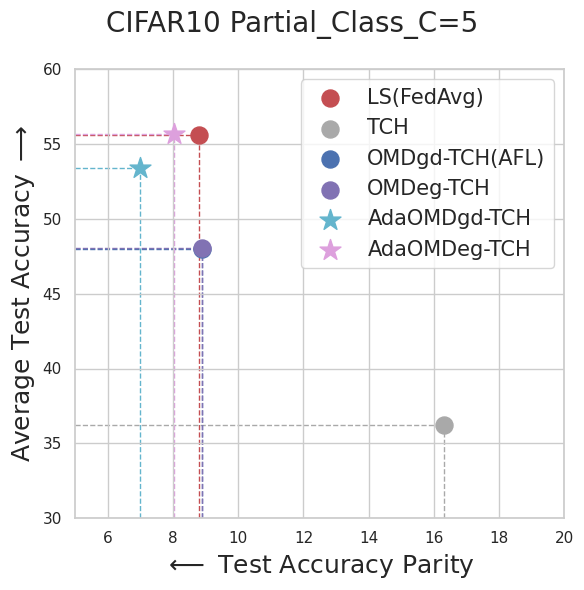

In [5]:
plot_scatters('CIFAR10', 'partial_class_ni5', seeds, 
              ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr0.3', 'AFLeg_new_llr0.03'], 
              ylimmin=30, ylimmax=60, xlimmin=5, xlimmax=20)